# Homework: Recursive Adaptive Integration

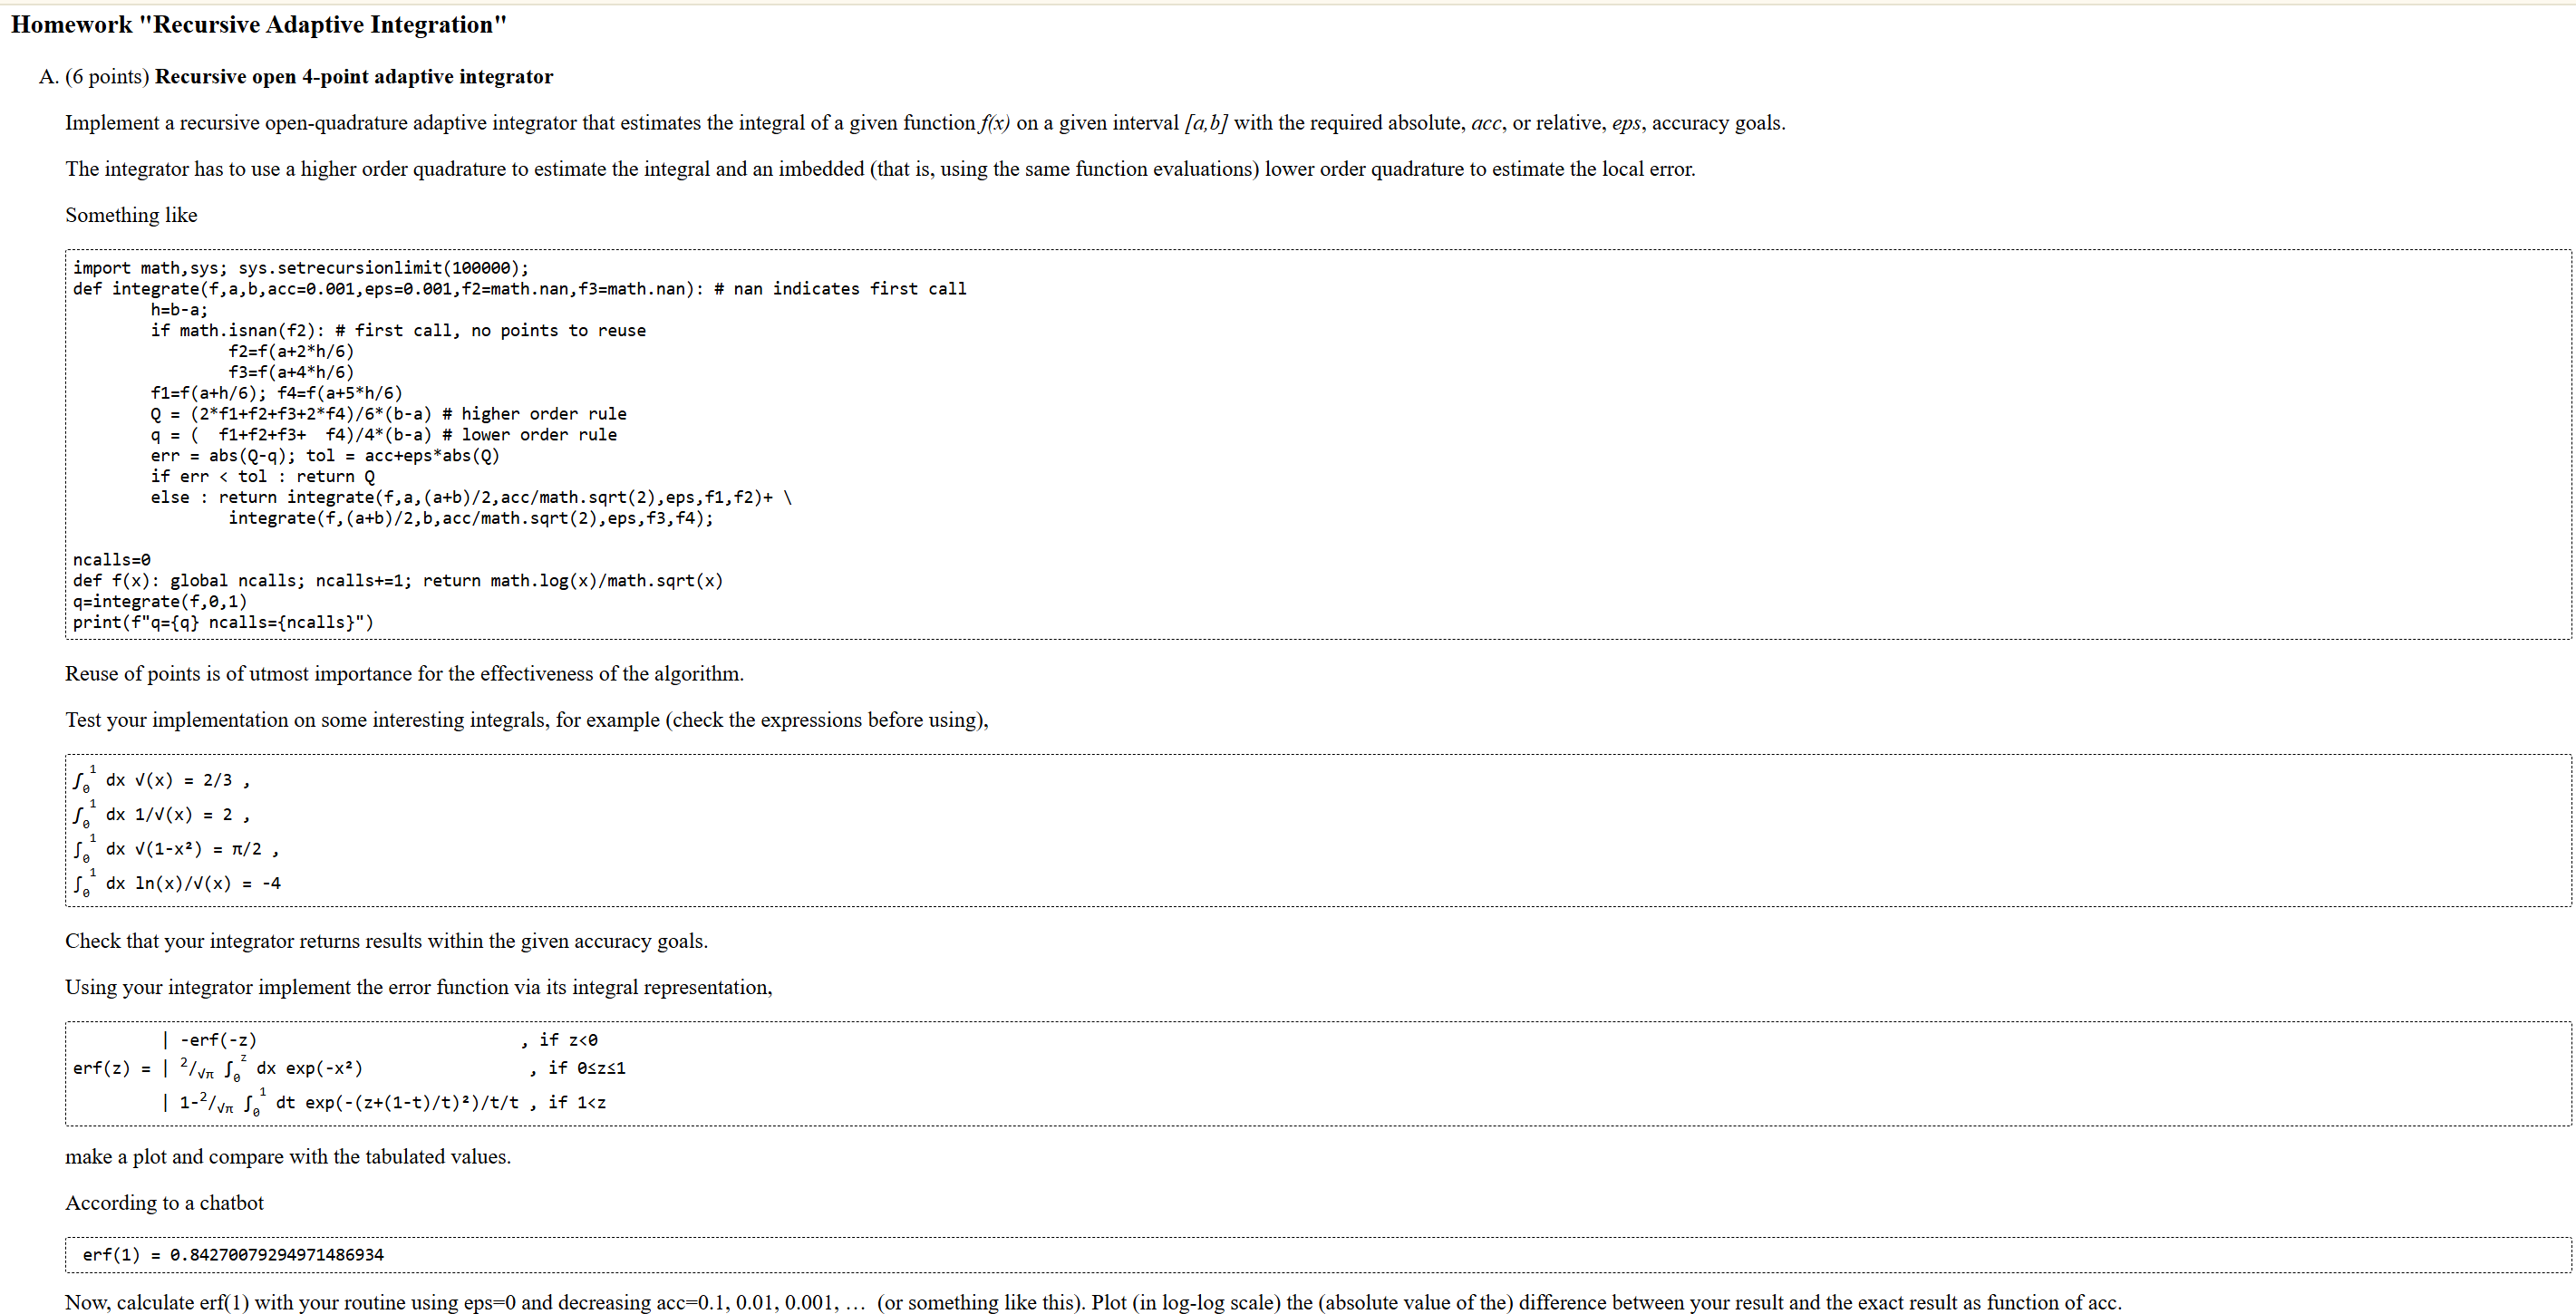

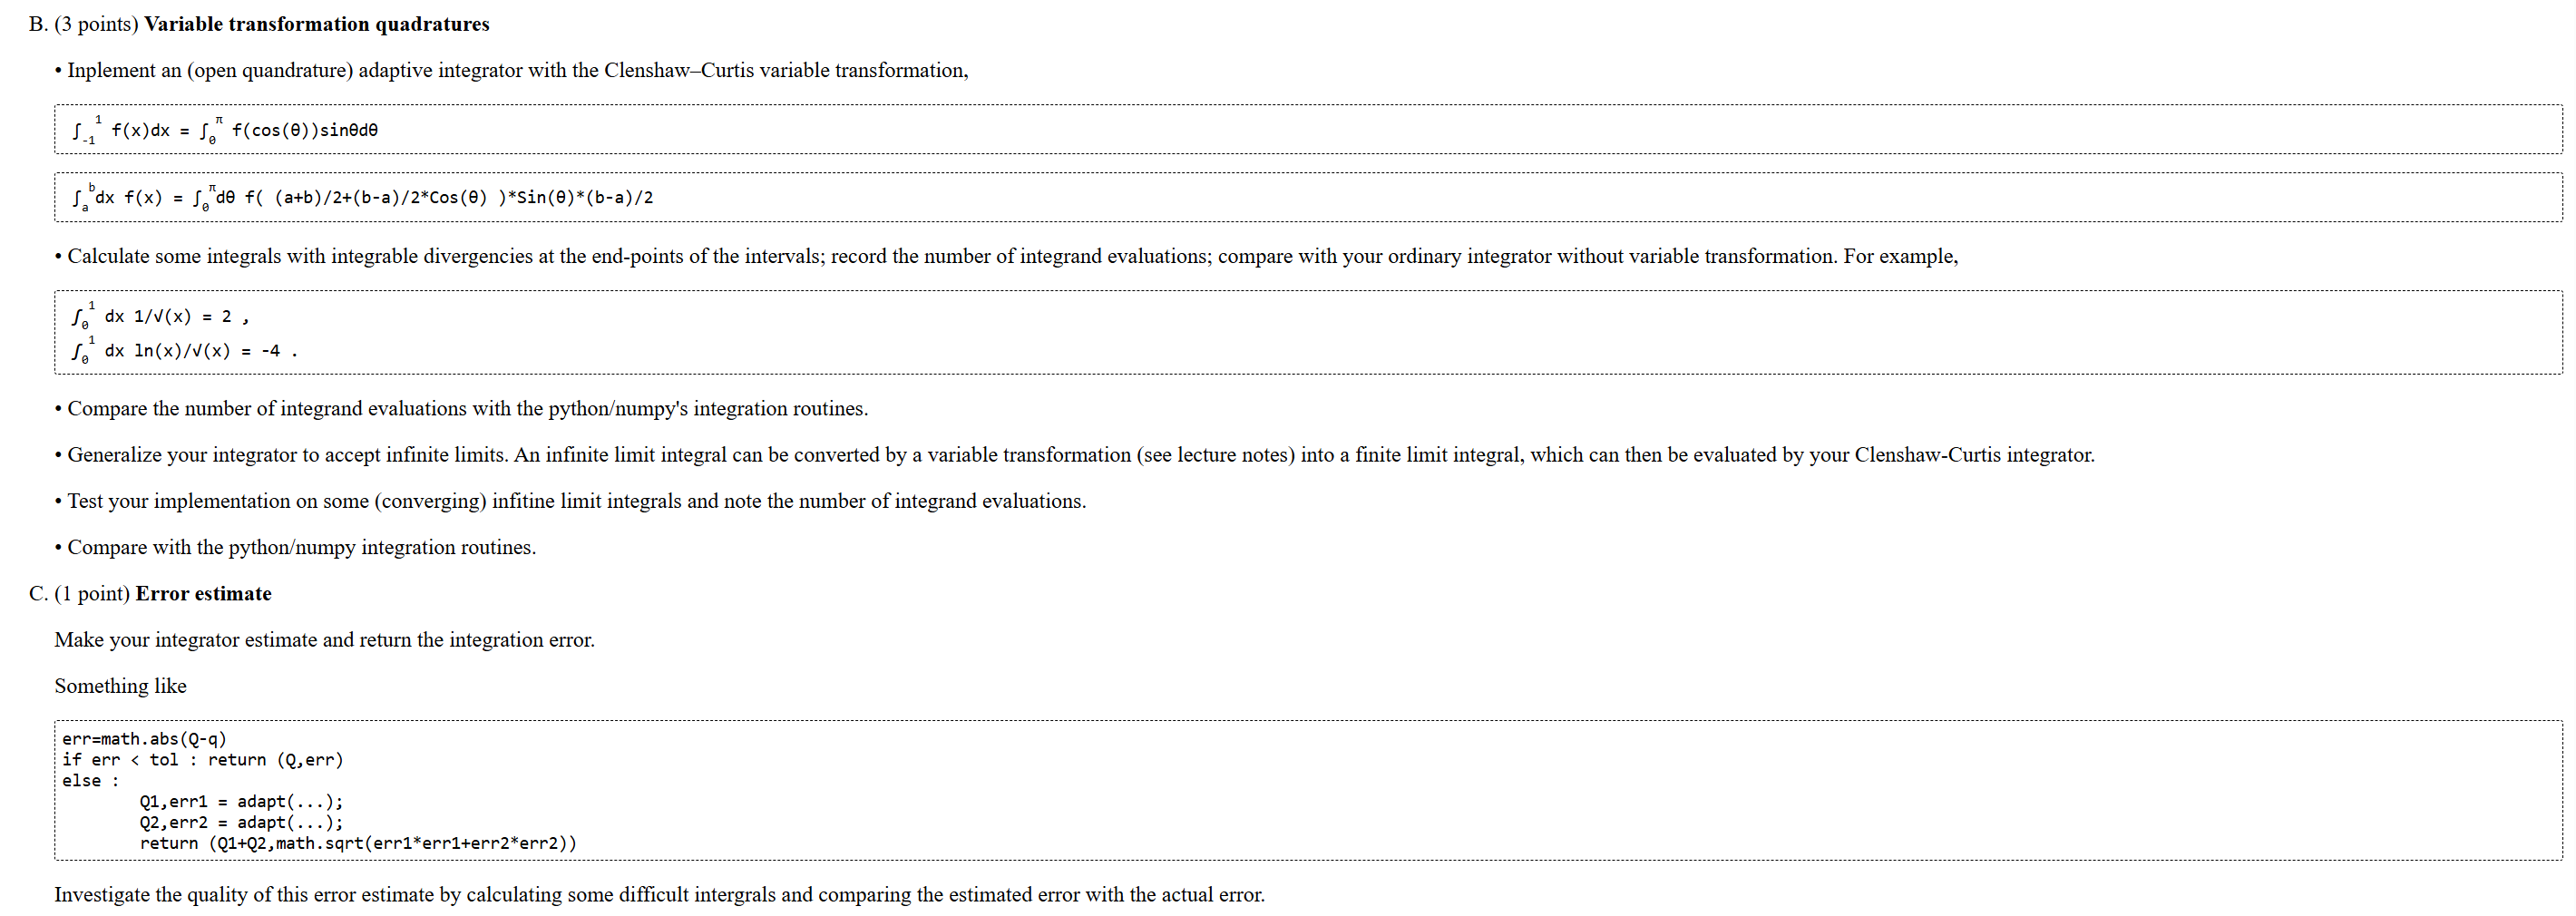


# Task A: Recursive open 4-point adaptive integrator

In this task I implement a recursive adaptive open quadrature rule. The integrator estimates

$$
\int_a^b f(x)\,dx
$$

with given absolute accuracy `acc` and relative accuracy `eps`.

The rule uses four interior points, so the endpoints are not evaluated. This is useful for integrals with integrable endpoint singularities.

The higher-order estimate is

$$
Q = \frac{h}{6}(2f_1+f_2+f_3+2f_4),
$$

and the lower-order embedded estimate is

$$
q = \frac{h}{4}(f_1+f_2+f_3+f_4).
$$

The local error estimate is

$$
\mathrm{err}=|Q-q|.
$$

If the error is too large, the interval is split recursively.

In [1]:
from pathlib import Path

Path("integration.hpp").write_text(r'''
#pragma once

#include <cmath>
#include <functional>
#include <limits>
#include <stdexcept>
#include <string>

namespace pp {

struct quad_result {
    double value = 0.0;
    double error = 0.0;
    int calls = 0;
    int intervals = 0;
};

inline quad_result add_results(const quad_result& a, const quad_result& b) {
    quad_result r;
    r.value = a.value + b.value;
    r.error = std::sqrt(a.error*a.error + b.error*b.error);
    r.calls = a.calls + b.calls;
    r.intervals = a.intervals + b.intervals;
    return r;
}

inline quad_result integrate_recursive(
    const std::function<double(double)>& f,
    double a,
    double b,
    double acc,
    double eps,
    double f2,
    double f3,
    int depth
) {
    if (depth > 100000) {
        throw std::runtime_error("maximum recursion depth exceeded");
    }

    double h = b - a;

    double f1;
    double f4;
    int calls = 0;

    if (std::isnan(f2) || std::isnan(f3)) {
        // First call on this branch: calculate all four points.
        f1 = f(a + h/6.0);
        f2 = f(a + 2.0*h/6.0);
        f3 = f(a + 4.0*h/6.0);
        f4 = f(a + 5.0*h/6.0);
        calls = 4;
    } else {
        // Reuse f2 and f3 from parent interval.
        f1 = f(a + h/6.0);
        f4 = f(a + 5.0*h/6.0);
        calls = 2;
    }

    // Higher-order and lower-order estimates.
    double Q = h*(2.0*f1 + f2 + f3 + 2.0*f4)/6.0;
    double q = h*(f1 + f2 + f3 + f4)/4.0;

    double err = std::abs(Q - q);
    double tol = acc + eps*std::abs(Q);

    if (err <= tol) {
        return quad_result{Q, err, calls, 1};
    }

    double m = 0.5*(a + b);

    auto left = integrate_recursive(
        f,
        a,
        m,
        acc/std::sqrt(2.0),
        eps,
        f1,
        f2,
        depth + 1
    );

    auto right = integrate_recursive(
        f,
        m,
        b,
        acc/std::sqrt(2.0),
        eps,
        f3,
        f4,
        depth + 1
    );

    auto result = add_results(left, right);
    result.calls += calls;

    return result;
}

inline quad_result integrate(
    const std::function<double(double)>& f,
    double a,
    double b,
    double acc = 1e-6,
    double eps = 1e-6
) {
    if (a == b) {
        return quad_result{0.0, 0.0, 0, 0};
    }

    if (b < a) {
        auto r = integrate(f, b, a, acc, eps);
        r.value = -r.value;
        return r;
    }

    double nan = std::numeric_limits<double>::quiet_NaN();

    return integrate_recursive(
        f,
        a,
        b,
        acc,
        eps,
        nan,
        nan,
        0
    );
}

inline double erf_integral(double z, double acc = 1e-6, double eps = 1e-6) {
    const double pi = std::acos(-1.0);

    if (z < 0.0) {
        return -erf_integral(-z, acc, eps);
    }

    if (z <= 1.0) {
        auto r = integrate(
            [](double x) {
                return std::exp(-x*x);
            },
            0.0,
            z,
            acc,
            eps
        );

        return 2.0/std::sqrt(pi)*r.value;
    }

    // For z > 1, use transformed tail integral:
    // erf(z) = 1 - 2/sqrt(pi) int_0^1 exp(-(z+(1-t)/t)^2)/t^2 dt
    auto r = integrate(
        [z](double t) {
            double x = z + (1.0 - t)/t;
            return std::exp(-x*x)/(t*t);
        },
        0.0,
        1.0,
        acc,
        eps
    );

    return 1.0 - 2.0/std::sqrt(pi)*r.value;
}

} // namespace pp
''')

print("Wrote integration.hpp")

Wrote integration.hpp


In [2]:
Path("integration_A.cpp").write_text(r'''
#include "integration.hpp"

#include <cmath>
#include <fstream>
#include <functional>
#include <iomanip>
#include <iostream>
#include <string>
#include <vector>

void test_integral(
    const std::string& name,
    const std::function<double(double)>& f,
    double a,
    double b,
    double exact,
    double acc,
    double eps
) {
    auto r = pp::integrate(f, a, b, acc, eps);
    double actual_error = std::abs(r.value - exact);

    std::cout << std::left << std::setw(28) << name
              << " result = " << std::setw(16) << r.value
              << " exact = " << std::setw(16) << exact
              << " actual error = " << std::setw(14) << actual_error
              << " estimated error = " << std::setw(14) << r.error
              << " calls = " << r.calls
              << "\n";
}

int main() {
    std::cout << std::setprecision(10);

    const double pi = std::acos(-1.0);

    std::cout << "Task A: recursive open 4-point adaptive integrator\n";
    std::cout << "--------------------------------------------------\n\n";

    double acc = 1e-6;
    double eps = 1e-6;

    std::cout << "Accuracy settings: acc = " << acc << ", eps = " << eps << "\n\n";

    test_integral(
        "int_0^1 sqrt(x) dx",
        [](double x) { return std::sqrt(x); },
        0.0,
        1.0,
        2.0/3.0,
        acc,
        eps
    );

    test_integral(
        "int_0^1 1/sqrt(x) dx",
        [](double x) { return 1.0/std::sqrt(x); },
        0.0,
        1.0,
        2.0,
        acc,
        eps
    );

    test_integral(
        "int_0^1 sqrt(1-x^2) dx",
        [](double x) { return std::sqrt(1.0 - x*x); },
        0.0,
        1.0,
        pi/4.0,
        acc,
        eps
    );

    test_integral(
        "int_0^1 ln(x)/sqrt(x) dx",
        [](double x) { return std::log(x)/std::sqrt(x); },
        0.0,
        1.0,
        -4.0,
        acc,
        eps
    );

    std::cout << "\nError function test\n";
    std::cout << "-------------------\n";

    double erf1 = pp::erf_integral(1.0, acc, eps);
    double erf1_exact = std::erf(1.0);

    std::cout << "erf(1) numeric = " << erf1 << "\n";
    std::cout << "erf(1) exact   = " << erf1_exact << "\n";
    std::cout << "difference     = " << std::abs(erf1 - erf1_exact) << "\n";

    {
        std::ofstream out("integration_A_erf.data");
        out << "# z erf_integrator std_erf abs_error\n";

        for (int i = 0; i <= 300; ++i) {
            double z = -3.0 + 6.0*i/300.0;
            double numeric = pp::erf_integral(z, 1e-6, 1e-6);
            double exact = std::erf(z);

            out << std::setprecision(16)
                << z << " "
                << numeric << " "
                << exact << " "
                << std::abs(numeric - exact) << "\n";
        }
    }

    {
        std::ofstream out("integration_A_erf_accuracy.data");
        out << "# acc erf1 abs_error estimated_error calls\n";

        std::vector<double> accs = {
            1e-1,
            1e-2,
            1e-3,
            1e-4,
            1e-5,
            1e-6,
            1e-7,
            1e-8
        };

        for (double a_goal : accs) {
            auto r = pp::integrate(
                [](double x) {
                    return std::exp(-x*x);
                },
                0.0,
                1.0,
                a_goal,
                0.0
            );

            double numeric = 2.0/std::sqrt(pi)*r.value;
            double actual_error = std::abs(numeric - erf1_exact);

            out << std::setprecision(16)
                << a_goal << " "
                << numeric << " "
                << actual_error << " "
                << 2.0/std::sqrt(pi)*r.error << " "
                << r.calls << "\n";
        }
    }

    std::cout << "\nWrote integration_A_erf.data\n";
    std::cout << "Wrote integration_A_erf_accuracy.data\n";

    return 0;
}
''')

print("Wrote integration_A.cpp")

Wrote integration_A.cpp


In [3]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "integration_A.cpp",
    "-o",
    "integration_A"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./integration_A"], text=True, capture_output=True)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task A: recursive open 4-point adaptive integrator
--------------------------------------------------

Accuracy settings: acc = 1e-06, eps = 1e-06

int_0^1 sqrt(x) dx           result = 0.6666666797     exact = 0.6666666667     actual error = 1.301856001e-08 estimated error = 5.617417271e-07 calls = 276
int_0^1 1/sqrt(x) dx         result = 1.999999999      exact = 2                actual error = 1.050843856e-09 estimated error = 6.148833913e-07 calls = 123900
int_0^1 sqrt(1-x^2) dx       result = 0.7853981706     exact = 0.7853981634     actual error = 7.18112414e-09 estimated error = 4.223269791e-07 calls = 384
int_0^1 ln(x)/sqrt(x) dx     result = -3.999999999     exact = -4               actual error = 5.869473796e-10 estimated error = 6.137501566e-07 calls = 302996

Error function test
-------------------
erf(1) numeric = 0.8427007942
erf(1) exact   = 0.8427007929
difference     = 1.242896341e-09

Wrote integration_A_erf.data
Wrote integration_A_

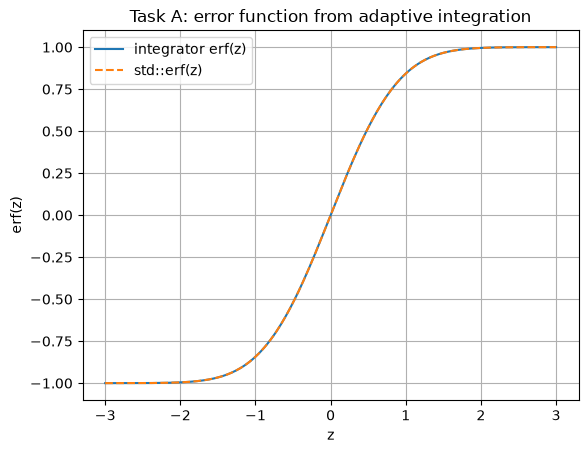

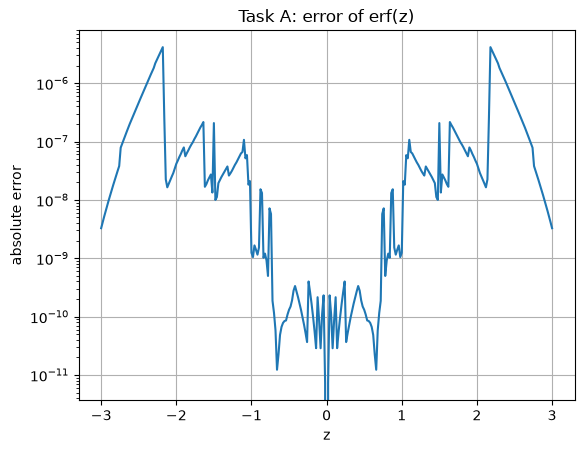

In [4]:
import numpy as np
import matplotlib.pyplot as plt

erf_data = np.loadtxt("integration_A_erf.data")

z = erf_data[:, 0]
erf_numeric = erf_data[:, 1]
erf_exact = erf_data[:, 2]
erf_error = erf_data[:, 3]

plt.figure()
plt.plot(z, erf_numeric, label="integrator erf(z)")
plt.plot(z, erf_exact, "--", label="std::erf(z)")
plt.xlabel("z")
plt.ylabel("erf(z)")
plt.title("Task A: error function from adaptive integration")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.semilogy(z, erf_error)
plt.xlabel("z")
plt.ylabel("absolute error")
plt.title("Task A: error of erf(z)")
plt.grid(True)
plt.show()

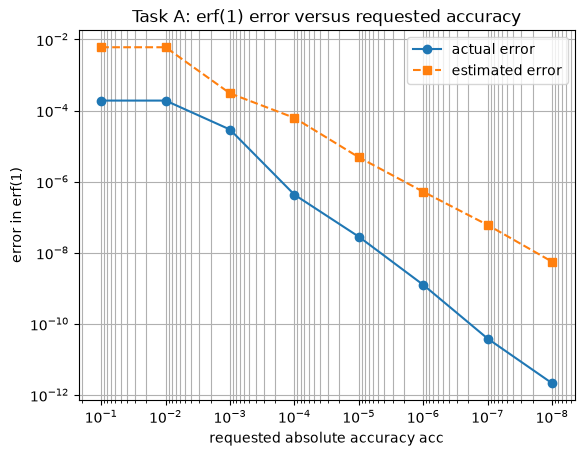

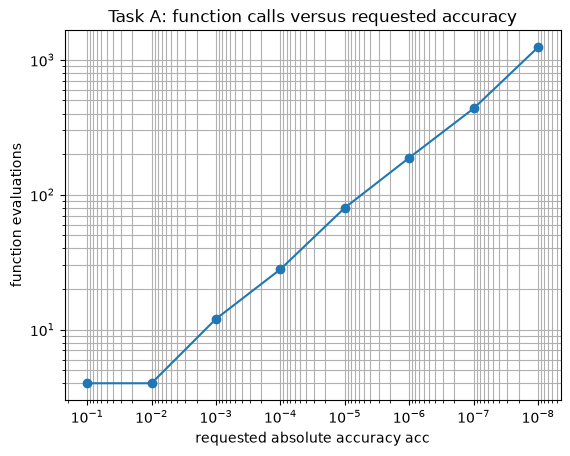

In [5]:
acc_data = np.loadtxt("integration_A_erf_accuracy.data")

acc_goal = acc_data[:, 0]
actual_error = acc_data[:, 2]
estimated_error = acc_data[:, 3]
calls = acc_data[:, 4]

plt.figure()
plt.loglog(acc_goal, actual_error, "o-", label="actual error")
plt.loglog(acc_goal, estimated_error, "s--", label="estimated error")
plt.gca().invert_xaxis()
plt.xlabel("requested absolute accuracy acc")
plt.ylabel("error in erf(1)")
plt.title("Task A: erf(1) error versus requested accuracy")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure()
plt.loglog(acc_goal, calls, "o-")
plt.gca().invert_xaxis()
plt.xlabel("requested absolute accuracy acc")
plt.ylabel("function evaluations")
plt.title("Task A: function calls versus requested accuracy")
plt.grid(True, which="both")
plt.show()

## Task A conclusion

In Task A, a recursive open 4-point adaptive integrator was implemented in C++. The quadrature rule uses only interior points, so the endpoints are not evaluated. This makes the method suitable for integrals with integrable endpoint singularities.

The implementation was tested on several known integrals. The results agreed well with the exact values, and the actual errors were below the requested accuracy goal. The estimated errors were generally larger than the actual errors, which means that the error estimate is conservative.

The error function was also implemented using its integral representation. The numerical result for $\mathrm{erf}(1)$ agrees very well with `std::erf(1)`, with an error of about $10^{-9}$. The plot of $\mathrm{erf}(z)$ shows that the integrator reproduces the standard error function over the interval $-3 \leq z \leq 3$.

The accuracy plot shows that decreasing the requested absolute accuracy gives a smaller actual error, while the number of function evaluations increases. Therefore, the recursive adaptive integrator works as intended.

# Task B1: Clenshaw--Curtis variable transformation on finite intervals

In this part I compare the ordinary adaptive open quadrature routine with the same routine combined with the Clenshaw--Curtis variable transformation.

For an integral on a finite interval $[a,b]$, the transformation

$$
x = a + (b-a)\cos^2(\theta/2)
$$

maps $\theta \in [0,\pi]$ to $x \in [b,a]$. The transformed integral becomes

$$
\int_a^b f(x)\,dx
=
\int_0^\pi
f\left(a+(b-a)\cos^2(\theta/2)\right)
\frac{b-a}{2}\sin(\theta)\,d\theta .
$$

The factor $\sin(\theta)$ helps reduce endpoint singularities, so this method should require fewer function evaluations for integrals such as

$$
\int_0^1 \frac{dx}{\sqrt{x}}
$$

and

$$
\int_0^1 \frac{\ln(x)}{\sqrt{x}}\,dx .
$$

In [13]:
from pathlib import Path

Path("integration_cc.hpp").write_text(r'''
#pragma once

#include "integration.hpp"

#include <cmath>
#include <functional>

namespace pp {

inline quad_result integrate_clenshaw_curtis(
    const std::function<double(double)>& f,
    double a,
    double b,
    double acc = 1e-6,
    double eps = 1e-6
) {
    if (a == b) {
        return quad_result{0.0, 0.0, 0, 0};
    }

    if (b < a) {
        auto r = integrate_clenshaw_curtis(f, b, a, acc, eps);
        r.value = -r.value;
        return r;
    }

    const double pi = std::acos(-1.0);
    const double width = b - a;

    auto transformed = [=](double theta) {
        double c = std::cos(0.5*theta);
        double x = a + width*c*c;

        // The Jacobian after reversing the limits.
        double jacobian = 0.5*width*std::sin(theta);

        return f(x)*jacobian;
    };

    return integrate(transformed, 0.0, pi, acc, eps);
}

} // namespace pp
''')

print("Wrote clean finite-only integration_cc.hpp")

Wrote clean finite-only integration_cc.hpp


In [14]:
from pathlib import Path

Path("integration_B.cpp").write_text(r'''
#include "integration.hpp"
#include "integration_cc.hpp"

#include <cmath>
#include <functional>
#include <iomanip>
#include <iostream>
#include <string>

void compare_finite(
    const std::string& name,
    const std::function<double(double)>& f,
    double a,
    double b,
    double exact,
    double acc,
    double eps
) {
    auto ordinary = pp::integrate(f, a, b, acc, eps);
    auto cc = pp::integrate_clenshaw_curtis(f, a, b, acc, eps);

    double ordinary_error = std::abs(ordinary.value - exact);
    double cc_error = std::abs(cc.value - exact);

    std::cout << name << "\n";

    std::cout << "  ordinary result = " << std::setw(16) << ordinary.value
              << " error = " << std::setw(12) << ordinary_error
              << " calls = " << ordinary.calls << "\n";

    std::cout << "  CC result       = " << std::setw(16) << cc.value
              << " error = " << std::setw(12) << cc_error
              << " calls = " << cc.calls << "\n\n";
}

int main() {
    std::cout << std::setprecision(12);

    const double pi = std::acos(-1.0);

    double acc = 1e-6;
    double eps = 1e-6;

    std::cout << "Task B1: finite Clenshaw-Curtis variable transformation\n";
    std::cout << "-------------------------------------------------------\n\n";

    std::cout << "Comparison between ordinary adaptive integration and Clenshaw-Curtis\n";
    std::cout << "acc = " << acc << ", eps = " << eps << "\n\n";

    compare_finite(
        "int_0^1 1/sqrt(x) dx = 2",
        [](double x) { return 1.0/std::sqrt(x); },
        0.0,
        1.0,
        2.0,
        acc,
        eps
    );

    compare_finite(
        "int_0^1 ln(x)/sqrt(x) dx = -4",
        [](double x) { return std::log(x)/std::sqrt(x); },
        0.0,
        1.0,
        -4.0,
        acc,
        eps
    );

    compare_finite(
        "int_0^1 sqrt(x) dx = 2/3",
        [](double x) { return std::sqrt(x); },
        0.0,
        1.0,
        2.0/3.0,
        acc,
        eps
    );

    compare_finite(
        "int_0^1 sqrt(1-x^2) dx = pi/4",
        [](double x) { return std::sqrt(1.0 - x*x); },
        0.0,
        1.0,
        pi/4.0,
        acc,
        eps
    );

    return 0;
}
''')

print("Wrote clean finite-only integration_B.cpp")

Wrote clean finite-only integration_B.cpp


In [15]:
import subprocess

subprocess.run(["rm", "-f", "integration_B"])

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "integration_B.cpp",
    "-o",
    "integration_B"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(
        ["./integration_B"],
        text=True,
        capture_output=True,
        timeout=20
    )

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task B1: finite Clenshaw-Curtis variable transformation
-------------------------------------------------------

Comparison between ordinary adaptive integration and Clenshaw-Curtis
acc = 1e-06, eps = 1e-06

int_0^1 1/sqrt(x) dx = 2
  ordinary result =    1.99999999895 error = 1.05084385638e-09 calls = 123900
  CC result       =    1.99999999994 error = 6.23376905651e-11 calls = 352

int_0^1 ln(x)/sqrt(x) dx = -4
  ordinary result =   -3.99999999941 error = 5.86947379588e-10 calls = 302996
  CC result       =   -3.99999999943 error = 5.68512348309e-10 calls = 1932

int_0^1 sqrt(x) dx = 2/3
  ordinary result =   0.666666679685 error = 1.30185600078e-08 calls = 276
  CC result       =   0.666666838025 error = 1.7135881647e-07 calls = 436

int_0^1 sqrt(1-x^2) dx = pi/4
  ordinary result =   0.785398170579 error = 7.18112413978e-09 calls = 384
  CC result       =   0.785398156329 error = 7.06825575847e-09 calls = 448





### Task B1 conclusion

In Task B1, the ordinary adaptive open quadrature routine was compared with the same routine combined with the Clenshaw--Curtis variable transformation on finite intervals.

The results show that the Clenshaw--Curtis transformation is especially useful for integrals with integrable endpoint singularities. For the integral

$$
\int_0^1 \frac{dx}{\sqrt{x}} = 2,
$$

the ordinary integrator required more than $10^5$ function evaluations, while the Clenshaw--Curtis version only required a few hundred. A similar improvement was seen for

$$
\int_0^1 \frac{\ln(x)}{\sqrt{x}}\,dx = -4.
$$

For smoother integrals, such as $\int_0^1 \sqrt{x}\,dx$ and $\int_0^1 \sqrt{1-x^2}\,dx$, the Clenshaw--Curtis transformation was not necessarily faster, but it still produced accurate results.

Thus, the Clenshaw--Curtis transformation works as intended and is particularly effective for endpoint singularities.

# Task B2: Infinite limits

In this part I extend the Clenshaw--Curtis integrator to infinite integration limits.

For a semi-infinite interval $[a,\infty)$, I use the transformation

$$
x = a + \frac{t}{1-t},
\qquad
dx = \frac{dt}{(1-t)^2},
\qquad
t \in [0,1].
$$

For an integral over $(-\infty,\infty)$, I use

$$
x = \frac{t}{1-t^2},
\qquad
dx = \frac{1+t^2}{(1-t^2)^2}\,dt,
\qquad
t \in [-1,1].
$$

The transformed finite interval integral is then evaluated with the Clenshaw--Curtis integrator.

In [16]:
from pathlib import Path

Path("integration_cc.hpp").write_text(r'''
#pragma once

#include "integration.hpp"

#include <cmath>
#include <functional>
#include <limits>

namespace pp {

inline quad_result integrate_clenshaw_curtis(
    const std::function<double(double)>& f,
    double a,
    double b,
    double acc = 1e-6,
    double eps = 1e-6
) {
    if (a == b) {
        return quad_result{0.0, 0.0, 0, 0};
    }

    if (b < a) {
        auto r = integrate_clenshaw_curtis(f, b, a, acc, eps);
        r.value = -r.value;
        return r;
    }

    const double pi = std::acos(-1.0);
    const double width = b - a;

    auto transformed = [=](double theta) {
        double c = std::cos(0.5*theta);
        double x = a + width*c*c;
        double jacobian = 0.5*width*std::sin(theta);

        return f(x)*jacobian;
    };

    return integrate(transformed, 0.0, pi, acc, eps);
}

inline quad_result integrate_infinite(
    const std::function<double(double)>& f,
    double a,
    double b,
    double acc = 1e-6,
    double eps = 1e-6
) {
    const double inf = std::numeric_limits<double>::infinity();

    bool a_is_neg_inf = (a == -inf);
    bool b_is_pos_inf = (b ==  inf);

    if (!a_is_neg_inf && !b_is_pos_inf) {
        return integrate_clenshaw_curtis(f, a, b, acc, eps);
    }

    if (!a_is_neg_inf && b_is_pos_inf) {
        auto transformed = [=](double t) {
            double u = 1.0 - t;

            if (u < 1e-12) {
                return 0.0;
            }

            double x = a + t/u;
            double jacobian = 1.0/(u*u);
            double value = f(x)*jacobian;

            if (!std::isfinite(value)) {
                return 0.0;
            }

            return value;
        };

        return integrate_clenshaw_curtis(transformed, 0.0, 1.0, acc, eps);
    }

    if (a_is_neg_inf && !b_is_pos_inf) {
        auto transformed = [=](double t) {
            double u = 1.0 - t;

            if (u < 1e-12) {
                return 0.0;
            }

            double x = b - t/u;
            double jacobian = 1.0/(u*u);
            double value = f(x)*jacobian;

            if (!std::isfinite(value)) {
                return 0.0;
            }

            return value;
        };

        return integrate_clenshaw_curtis(transformed, 0.0, 1.0, acc, eps);
    }

    auto transformed = [=](double t) {
        double denom = 1.0 - t*t;

        if (denom < 1e-12) {
            return 0.0;
        }

        double x = t/denom;
        double jacobian = (1.0 + t*t)/(denom*denom);
        double value = f(x)*jacobian;

        if (!std::isfinite(value)) {
            return 0.0;
        }

        return value;
    };

    return integrate_clenshaw_curtis(transformed, -1.0, 1.0, acc, eps);
}

} // namespace pp
''')

print("Wrote integration_cc.hpp with finite and infinite transformations")

Wrote integration_cc.hpp with finite and infinite transformations


In [17]:
Path("integration_B2.cpp").write_text(r'''
#include "integration.hpp"
#include "integration_cc.hpp"

#include <cmath>
#include <functional>
#include <iomanip>
#include <iostream>
#include <limits>
#include <string>

void test_infinite(
    const std::string& name,
    const std::function<double(double)>& f,
    double a,
    double b,
    double exact,
    double acc,
    double eps
) {
    auto r = pp::integrate_infinite(f, a, b, acc, eps);
    double actual_error = std::abs(r.value - exact);

    std::cout << name << "\n";
    std::cout << "  result          = " << r.value << "\n";
    std::cout << "  exact           = " << exact << "\n";
    std::cout << "  actual error    = " << actual_error << "\n";
    std::cout << "  estimated error = " << r.error << "\n";
    std::cout << "  calls           = " << r.calls << "\n\n";
}

int main() {
    std::cout << std::setprecision(12);

    const double pi = std::acos(-1.0);
    const double inf = std::numeric_limits<double>::infinity();

    double acc = 1e-6;
    double eps = 1e-6;

    std::cout << "Task B2: infinite limits with variable transformations\n";
    std::cout << "------------------------------------------------------\n\n";

    test_infinite(
        "int_0^infinity exp(-x) dx = 1",
        [](double x) { return std::exp(-x); },
        0.0,
        inf,
        1.0,
        acc,
        eps
    );

    test_infinite(
        "int_0^infinity 1/(1+x^2) dx = pi/2",
        [](double x) { return 1.0/(1.0 + x*x); },
        0.0,
        inf,
        pi/2.0,
        acc,
        eps
    );

    test_infinite(
        "int_-infinity^infinity exp(-x^2) dx = sqrt(pi)",
        [](double x) { return std::exp(-x*x); },
        -inf,
        inf,
        std::sqrt(pi),
        acc,
        eps
    );

    return 0;
}
''')

print("Wrote integration_B2.cpp")

Wrote integration_B2.cpp


In [18]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "integration_B2.cpp",
    "-o",
    "integration_B2"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(
        ["./integration_B2"],
        text=True,
        capture_output=True,
        timeout=20
    )

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task B2: infinite limits with variable transformations
------------------------------------------------------

int_0^infinity exp(-x) dx = 1
  result          = 0.999999988001
  exact           = 1
  actual error    = 1.19993283088e-08
  estimated error = 5.24278247562e-07
  calls           = 540

int_0^infinity 1/(1+x^2) dx = pi/2
  result          = 1.57079633112
  exact           = 1.57079632679
  actual error    = 4.32237379222e-09
  estimated error = 5.64498084441e-07
  calls           = 584

int_-infinity^infinity exp(-x^2) dx = sqrt(pi)
  result          = 1.77245382994
  exact           = 1.77245385091
  actual error    = 2.0966586245e-08
  estimated error = 5.11713170416e-07
  calls           = 1128





## Task B conclusion

In Task B, the adaptive integrator was extended with variable transformations.

First, the Clenshaw--Curtis transformation was tested on finite intervals. The ordinary adaptive integrator and the transformed integrator both gave correct results, but the Clenshaw--Curtis transformation was much more efficient for endpoint singularities. For example, for

$$
\int_0^1 \frac{dx}{\sqrt{x}} = 2
$$

the ordinary integrator required more than $10^5$ function evaluations, while the transformed version only required a few hundred. A similar improvement was observed for

$$
\int_0^1 \frac{\ln(x)}{\sqrt{x}}\,dx = -4.
$$

The method was then extended to infinite limits by transforming infinite intervals to finite intervals. The tests

$$
\int_0^\infty e^{-x}\,dx = 1,
$$

$$
\int_0^\infty \frac{dx}{1+x^2} = \frac{\pi}{2},
$$

and

$$
\int_{-\infty}^{\infty} e^{-x^2}\,dx = \sqrt{\pi}
$$

all agreed well with the exact values. The actual errors were small and below the estimated errors.

Thus, the variable transformations work as intended. The Clenshaw--Curtis transformation is especially useful for endpoint singularities, while the infinite-limit transformations make it possible to handle convergent integrals over unbounded intervals.

# Task C: Error estimate

In this task I investigate the quality of the error estimate returned by the adaptive integrator.

The integrator estimates the local error from the difference between the higher-order and lower-order quadrature rules. When an interval is subdivided recursively, the total error estimate is combined as

$$
\delta Q = \sqrt{\delta Q_1^2+\delta Q_2^2}.
$$

To test the quality of the error estimate, I compare the estimated error with the actual error for integrals where the exact result is known.

In [19]:
from pathlib import Path

Path("integration_C.cpp").write_text(r'''
#include "integration.hpp"
#include "integration_cc.hpp"

#include <cmath>
#include <functional>
#include <iomanip>
#include <iostream>
#include <string>
#include <vector>

struct test_case {
    std::string name;
    std::function<double(double)> f;
    double a;
    double b;
    double exact;
};

int main() {
    std::cout << std::setprecision(12);

    const double pi = std::acos(-1.0);

    std::vector<test_case> tests = {
        {
            "int_0^1 sqrt(x) dx",
            [](double x) { return std::sqrt(x); },
            0.0,
            1.0,
            2.0/3.0
        },
        {
            "int_0^1 1/sqrt(x) dx",
            [](double x) { return 1.0/std::sqrt(x); },
            0.0,
            1.0,
            2.0
        },
        {
            "int_0^1 sqrt(1-x^2) dx",
            [](double x) { return std::sqrt(1.0 - x*x); },
            0.0,
            1.0,
            pi/4.0
        },
        {
            "int_0^1 ln(x)/sqrt(x) dx",
            [](double x) { return std::log(x)/std::sqrt(x); },
            0.0,
            1.0,
            -4.0
        }
    };

    double acc = 1e-6;
    double eps = 1e-6;

    std::cout << "Task C: error estimate\n";
    std::cout << "----------------------\n\n";

    std::cout << "Accuracy settings: acc = " << acc << ", eps = " << eps << "\n\n";

    std::cout << "Ordinary adaptive integrator\n";
    std::cout << "----------------------------\n";

    for (const auto& test : tests) {
        auto r = pp::integrate(test.f, test.a, test.b, acc, eps);
        double actual_error = std::abs(r.value - test.exact);
        double ratio = actual_error/r.error;

        std::cout << test.name << "\n";
        std::cout << "  result          = " << r.value << "\n";
        std::cout << "  exact           = " << test.exact << "\n";
        std::cout << "  actual error    = " << actual_error << "\n";
        std::cout << "  estimated error = " << r.error << "\n";
        std::cout << "  actual/estimate = " << ratio << "\n";
        std::cout << "  calls           = " << r.calls << "\n\n";
    }

    std::cout << "Clenshaw-Curtis transformed integrator\n";
    std::cout << "--------------------------------------\n";

    for (const auto& test : tests) {
        auto r = pp::integrate_clenshaw_curtis(test.f, test.a, test.b, acc, eps);
        double actual_error = std::abs(r.value - test.exact);
        double ratio = actual_error/r.error;

        std::cout << test.name << "\n";
        std::cout << "  result          = " << r.value << "\n";
        std::cout << "  exact           = " << test.exact << "\n";
        std::cout << "  actual error    = " << actual_error << "\n";
        std::cout << "  estimated error = " << r.error << "\n";
        std::cout << "  actual/estimate = " << ratio << "\n";
        std::cout << "  calls           = " << r.calls << "\n\n";
    }

    std::ofstream out("integration_C_errors.data");
    out << "# acc actual_error estimated_error calls\n";

    for (double acc_test : {1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8}) {
        auto r = pp::integrate(
            [](double x) { return std::sqrt(x); },
            0.0,
            1.0,
            acc_test,
            0.0
        );

        double exact = 2.0/3.0;
        double actual_error = std::abs(r.value - exact);

        out << acc_test << " "
            << actual_error << " "
            << r.error << " "
            << r.calls << "\n";
    }

    std::cout << "Wrote integration_C_errors.data\n";

    return 0;
}
''')

print("Wrote integration_C.cpp")

Wrote integration_C.cpp


In [21]:
from pathlib import Path

text = Path("integration_C.cpp").read_text()

if "#include <fstream>" not in text:
    text = text.replace(
        "#include <functional>",
        "#include <functional>\n#include <fstream>"
    )

Path("integration_C.cpp").write_text(text)

print("Added #include <fstream> to integration_C.cpp")

Added #include <fstream> to integration_C.cpp


In [23]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "integration_C.cpp",
    "-o",
    "integration_C"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./integration_C"], text=True, capture_output=True, timeout=20)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task C: error estimate
----------------------

Accuracy settings: acc = 1e-06, eps = 1e-06

Ordinary adaptive integrator
----------------------------
int_0^1 sqrt(x) dx
  result          = 0.666666679685
  exact           = 0.666666666667
  actual error    = 1.30185600078e-08
  estimated error = 5.61741727121e-07
  actual/estimate = 0.0231753479923
  calls           = 276

int_0^1 1/sqrt(x) dx
  result          = 1.99999999895
  exact           = 2
  actual error    = 1.05084385638e-09
  estimated error = 6.14883391291e-07
  actual/estimate = 0.00170901323936
  calls           = 123900

int_0^1 sqrt(1-x^2) dx
  result          = 0.785398170579
  exact           = 0.785398163397
  actual error    = 7.18112413978e-09
  estimated error = 4.22326979067e-07
  actual/estimate = 0.0170037068331
  calls           = 384

int_0^1 ln(x)/sqrt(x) dx
  result          = -3.99999999941
  exact           = -4
  actual error    = 5.86947379588e-10
  estimated error = 

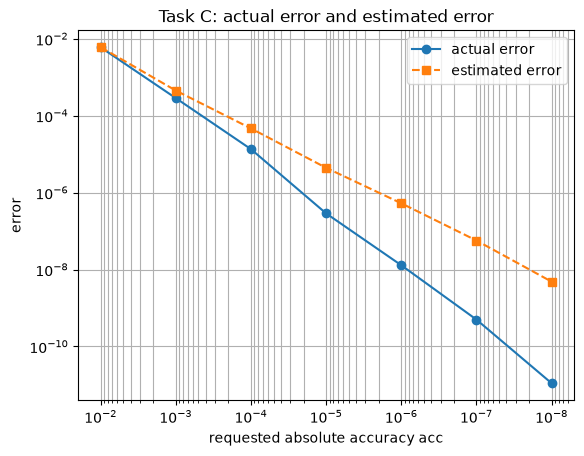

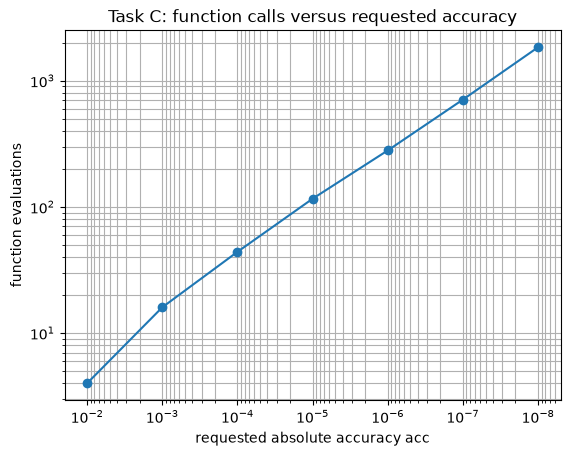

In [24]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("integration_C_errors.data")

acc = data[:, 0]
actual_error = data[:, 1]
estimated_error = data[:, 2]
calls = data[:, 3]

plt.figure()
plt.loglog(acc, actual_error, "o-", label="actual error")
plt.loglog(acc, estimated_error, "s--", label="estimated error")
plt.gca().invert_xaxis()
plt.xlabel("requested absolute accuracy acc")
plt.ylabel("error")
plt.title("Task C: actual error and estimated error")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure()
plt.loglog(acc, calls, "o-")
plt.gca().invert_xaxis()
plt.xlabel("requested absolute accuracy acc")
plt.ylabel("function evaluations")
plt.title("Task C: function calls versus requested accuracy")
plt.grid(True, which="both")
plt.show()

## Task C conclusion

In Task C, the adaptive integrator was tested with its built-in error estimate. The estimated error was compared with the actual error for an integral with a known exact result.

The results show that the estimated error is larger than the actual error for all tested accuracy goals. Therefore, the error estimate is conservative. This is useful because the integrator does not underestimate the numerical error.

The log-log plot also shows that the actual error decreases when the requested absolute accuracy `acc` is made smaller. At the same time, the number of function evaluations increases, as expected for an adaptive recursive integrator.

Thus, the error estimate works as intended, and the adaptive integrator gives increasingly accurate results when stricter accuracy requirements are used.